In [1]:
from langgraph.graph import StateGraph, START
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
import requests

ImportError: cannot import name 'ModelProfile' from 'langchain_core.language_models' (c:\Users\HP840G6\AppData\Local\Programs\Python\Python311\Lib\site-packages\langchain_core\language_models\__init__.py)

In [2]:
load_dotenv()

True

In [16]:
llm=ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.7
)

In [17]:
@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = (
        "https://www.alphavantage.co/query"
        f"?function=GLOBAL_QUOTE&symbol={symbol}&apikey=C9PE94QUEW9VWGFM"
    )
    r = requests.get(url)
    return r.json()

In [18]:
@tool
def purchase_stock(symbol: str, quantity: int) -> dict:
    """
    Simulate purchasing a given quantity of a stock symbol.

    HUMAN-IN-THE-LOOP:
    Before confirming the purchase, this tool will interrupt
    and wait for a human decision ("yes" / anything else).
    """
    
    decision = interrupt(f"Approve buying {quantity} shares of {symbol}? (yes/no)")

    if isinstance(decision, str) and decision.lower() == "yes":
        return {
            "status": "success",
            "message": f"Purchase order placed for {quantity} shares of {symbol}.",
            "symbol": symbol,
            "quantity": quantity,
        }
    
    else:
        return {
            "status": "cancelled",
            "message": f"Purchase of {quantity} shares of {symbol} was declined by human.",
            "symbol": symbol,
            "quantity": quantity,
        }



In [19]:
tools = [get_stock_price, purchase_stock]
llm_with_tools = llm.bind_tools(tools)

In [20]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [21]:
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}
tool_node = ToolNode(tools)

In [22]:
memory = MemorySaver()


In [23]:
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chat_node")

graph.add_conditional_edges("chat_node", tools_condition)
graph.add_edge("tools", "chat_node")

chatbot = graph.compile(checkpointer=memory)

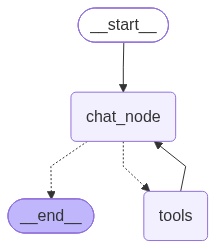

In [24]:
chatbot

In [ ]:
if __name__ == "__main__":
    thread_id = "demo-thread"

    while True:
        user_input = input("You: ")
        if user_input.lower().strip() in {"exit", "quit"}:
            print("Goodbye!")
            break
        state = {"messages": [HumanMessage(content=user_input)]}
        result = chatbot.invoke(
            state,
            config={"configurable": {"thread_id": thread_id}},
        )
        interrupts = result.get("__interrupt__", [])

        if interrupts:
           
            prompt_to_human = interrupts[0].value
            print(f"HITL: {prompt_to_human}")
            decision = input("Your decision: ").strip().lower()

            
            result = chatbot.invoke(
                Command(resume=decision),
                config={"configurable": {"thread_id": thread_id}},
            )

        messages = result["messages"]
        last_msg = messages[-1]
        print(f"Bot: {last_msg.content}\n")


Bot: Hello! How can I help you today?

Bot: Sure thing! 🍎

It sounds like you’d like to buy shares of Apple (AAPL). How many shares would you like to purchase?

HITL: Approve buying 10 shares of AAPL? (yes/no)
Bot: Your purchase order has been placed successfully:

- **Symbol:** AAPL (Apple Inc.)  
- **Quantity:** 10 shares  

Let me know if there’s anything else you’d like to do—check the current price, view your portfolio, or make another trade!

Bot: Got it! 🚗

How many Tesla (TSLA) shares would you like to purchase?

HITL: Approve buying 30 shares of TSLA? (yes/no)
Bot: Your request to buy **30 shares of Tesla (TSLA)** was cancelled.

Would you like to:

1. Try purchasing a different quantity of TSLA?  
2. Choose a different stock?  
3. Do something else (e.g., check prices, view portfolio)?

Just let me know what you’d like to do!

